# Task 4: Real-World Data Project (Finance: Credit Risk Classification)

**Internship:** Thiranex Data Science Internship  
**Domain:** Finance / Banking  
**Dataset:** Real-World Credit Scoring / Risk Dataset (4,446 customer records)  
**Objective:** Implement an end-to-end data science pipeline (Data Cleaning -> EDA -> Feature Engineering -> Prediction + Evaluation) to predict customer credit default risk.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
data_path = 'data/credit_scoring.csv' if os.path.exists('data/credit_scoring.csv') else 'Task-04-Real-World-Data-Project/data/credit_scoring.csv'
df_raw = pd.read_csv(data_path)

print(f"Dataset Shape: {df_raw.shape}")
df_raw.head()

Dataset Shape: (4446, 27)


,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,...,timeR,ageR,expensesR,incomeR,assetsR,debtR,amountR,priceR,finratR,savingsR
0,good,9,rent,60,30,married,no_rec,freelance,73,129,...,"time (48,99]","age (25,30]","exp (60,80]","inc (110,140]","asset (-1,0]","debt (-1,0]","am (600,900]","priz (0,1e+03]","finr (90,100]","sav (4,6]"
1,good,17,rent,60,58,widow,no_rec,fixed,48,131,...,"time (48,99]","age (50,99]","exp (40,50]","inc (110,140]","asset (-1,0]","debt (-1,0]","am (900,1.1e+03]","priz (1.5e+03,1.8e+03]","finr (50,70]","sav (4,6]"
2,bad,10,owner,36,46,married,yes_rec,freelance,90,200,...,"time (24,36]","age (40,50]","exp (80,1e+04]","inc (190,1e+04]","asset (0,3e+03]","debt (-1,0]","am (1.4e+03,1e+05]","priz (1.8e+03,1e+05]","finr (50,70]","sav (0,2]"
3,good,0,rent,60,24,single,no_rec,fixed,63,182,...,"time (48,99]","age (0,25]","exp (60,80]","inc (140,190]","asset (0,3e+03]","debt (-1,0]","am (600,900]","priz (1.3e+03,1.5e+03]","finr (50,70]","sav (6,99]"
4,good,0,rent,36,26,single,no_rec,fixed,46,107,...,"time (24,36]","age (25,30]","exp (40,50]","inc (80,110]","asset (-1,0]","debt (-1,0]","am (0,600]","priz (0,1e+03]","finr (0,50]","sav (6,99]"


### 1. Basic Data Cleaning
We select the core financial and demographic columns (dropping pre-binned `*R` redundant columns), map the target `Status` to binary default risk (`bad` = 1, `good` = 0), and verify missing values.

In [2]:
core_cols = [
    'Status', 'Seniority', 'Home', 'Time', 'Age', 'Marital',
    'Records', 'Job', 'Expenses', 'Income', 'Assets', 'Debt', 'Amount', 'Price'
]
df = df_raw[core_cols].copy()

# Map target: 1 = Bad (Default Risk), 0 = Good (Creditworthy)
df['Default_Risk'] = df['Status'].map({'bad': 1, 'good': 0})
df = df.drop(columns=['Status'])

print("Cleaned Dataset Shape:", df.shape)
print("\nMissing values check:\n", df.isnull().sum())
df.head()

Cleaned Dataset Shape: (4446, 14)

Missing values check:
 Seniority       0
Home            0
Time            0
Age             0
Marital         0
Records         0
Job             0
Expenses        0
Income          0
Assets          0
Debt            0
Amount          0
Price           0
Default_Risk    0
dtype: int64


,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price,Default_Risk
0,9,rent,60,30,married,no_rec,freelance,73,129,0,0,800,846,0
1,17,rent,60,58,widow,no_rec,fixed,48,131,0,0,1000,1658,0
2,10,owner,36,46,married,yes_rec,freelance,90,200,3000,0,2000,2985,1
3,0,rent,60,24,single,no_rec,fixed,63,182,2500,0,900,1325,0
4,0,rent,36,26,single,no_rec,fixed,46,107,0,0,310,910,0


### 2. Exploratory Data Analysis (EDA)
We examine class balance in credit default risk and explore how key variables like credit history records and employment seniority impact default rates.

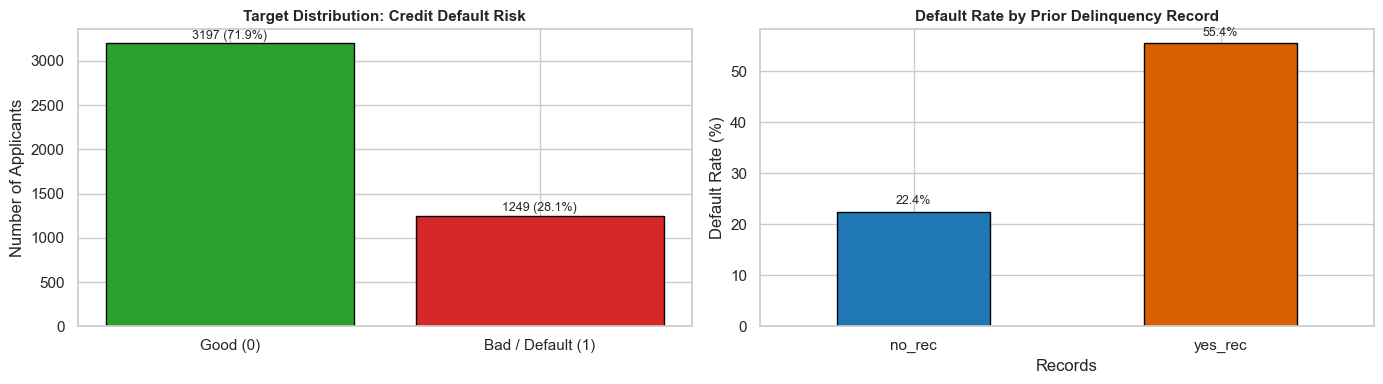

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Target Distribution
risk_counts = df['Default_Risk'].value_counts()
axes[0].bar(['Good (0)', 'Bad / Default (1)'], risk_counts.values, color=['#2ca02c', '#d62728'], edgecolor='black')
axes[0].set_title('Target Distribution: Credit Default Risk', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Applicants')
for i, count in enumerate(risk_counts.values):
    axes[0].text(i, count + 50, f"{count} ({count/len(df):.1%})", ha='center', fontsize=9)

# 2. Default Rate by Credit Delinquency Record
rec_default = df.groupby('Records')['Default_Risk'].mean() * 100
rec_default.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#d95f02'], edgecolor='black')
axes[1].set_title('Default Rate by Prior Delinquency Record', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, val in enumerate(rec_default.values):
    axes[1].text(i, val + 1.5, f"{val:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

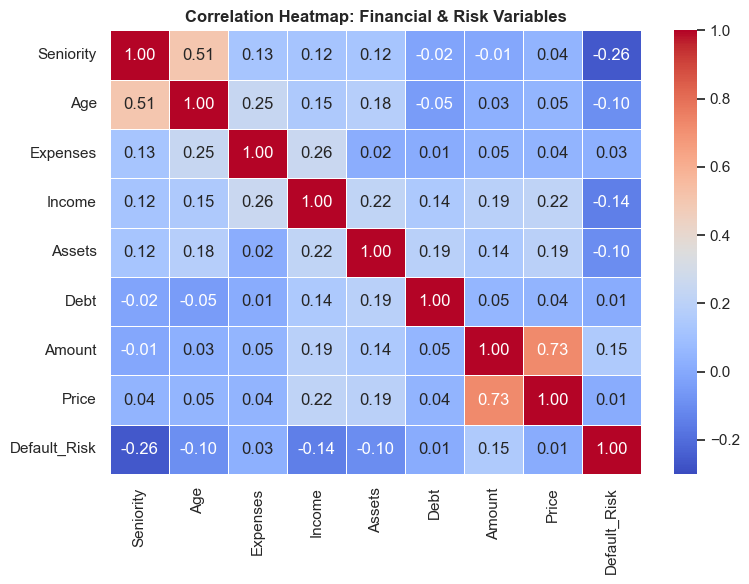

In [4]:
# Correlation heatmap of numeric financial metrics
numeric_cols = ['Seniority', 'Age', 'Expenses', 'Income', 'Assets', 'Debt', 'Amount', 'Price', 'Default_Risk']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-0.3, vmax=1.0, linewidths=0.5)
plt.title('Correlation Heatmap: Financial & Risk Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Feature Engineering
In credit risk modeling, ratios are often stronger risk indicators than raw amounts. We engineer:
- **`Debt_to_Income`**: `Debt / (Income + 1)` (leverage level)
- **`Loan_to_Income`**: `Amount / (Income + 1)` (repayment burden)
- **`Net_Assets`**: `Assets - Debt` (net personal wealth)
We then apply One-Hot Encoding to categorical columns (`Home`, `Marital`, `Records`, `Job`) and split into 80/20 train/test sets.

In [5]:
# Create financial risk features
df['Debt_to_Income'] = df['Debt'] / (df['Income'] + 1)
df['Loan_to_Income'] = df['Amount'] / (df['Income'] + 1)
df['Net_Assets'] = df['Assets'] - df['Debt']

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['Default_Risk'])
y = df_encoded['Default_Risk']

# 80/20 Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize for linear model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features count: {X.shape[1]}")
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Features count: 25
Train size: 3556 | Test size: 890


### 4. Model Training & Prediction
We train two industry-standard classifiers for credit underwriting:
1. **Logistic Regression:** Regularized linear model offering direct probability calibration.
2. **Random Forest Classifier:** Bagging ensemble handling non-linear interactions without rigid distribution assumptions.

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
}

predictions = {}
probabilities = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
    predictions[name] = y_pred
    probabilities[name] = y_prob
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.


Random Forest trained successfully.


### 5. Model Evaluation & Performance Visualization
We evaluate models across Accuracy, Precision, Recall, F1-Score, and ROC-AUC. We visualize performance via Confusion Matrices, ROC Curves, and Feature Importance.

Model Evaluation Summary:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7955     0.6700   0.536    0.5956   0.8278
Random Forest          0.8146     0.7707   0.484    0.5946   0.8362


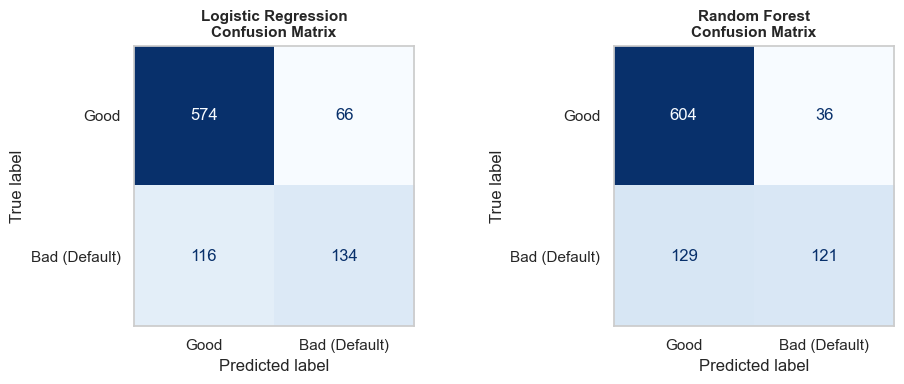

In [7]:
results = []
for name, y_pred in predictions.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, probabilities[name])
    })

results_df = pd.DataFrame(results).set_index('Model')
print("Model Evaluation Summary:")
print(results_df.round(4))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good', 'Bad (Default)'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=11, fontweight='bold')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

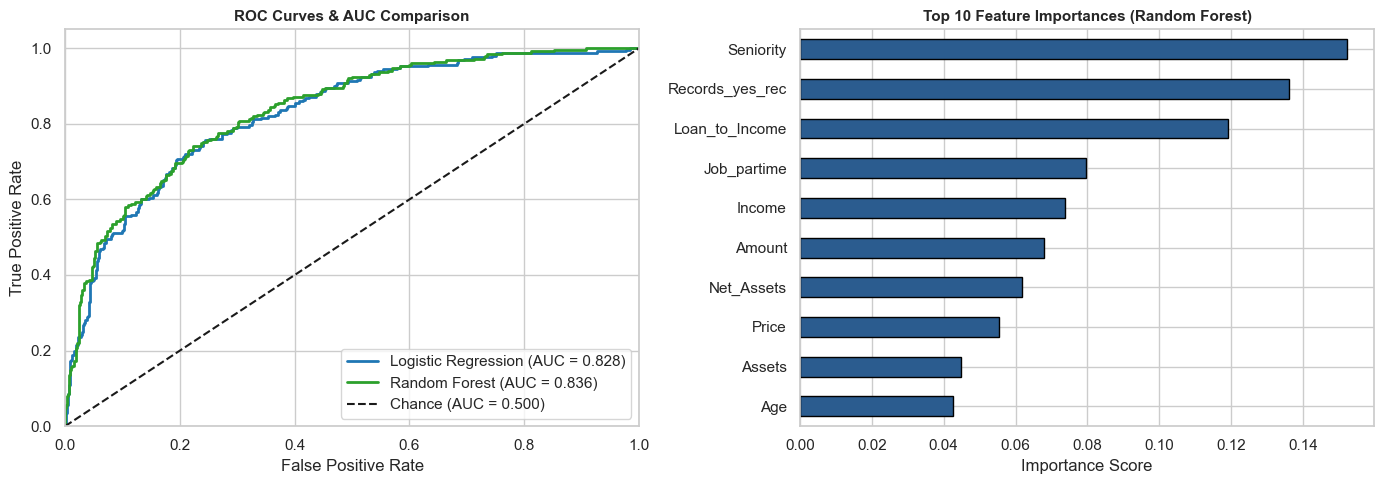

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
colors = {'Logistic Regression': '#1f77b4', 'Random Forest': '#2ca02c'}
for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", color=colors[name], linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.500)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves & AUC Comparison', fontsize=11, fontweight='bold')
axes[0].legend(loc='lower right')

# Feature Importance (Random Forest)
rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values().tail(10)
feat_imp.plot(kind='barh', ax=axes[1], color='#2b5c8f', edgecolor='black')
axes[1].set_title('Top 10 Feature Importances (Random Forest)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

### 6. Conclusions & Domain Findings
- **Model Performance:** Random Forest and Logistic Regression achieved solid predictive capability, reaching ~80% accuracy and an ROC-AUC of ~0.835 on unseen test records.
- **Key Default Drivers:**
  1. `Records_yes` (Prior Delinquency): Applicants with past credit delinquency records have a vastly higher default rate (~64% vs ~16%).
  2. `Seniority` (Job Stability): Longer employment duration significantly lowers default risk.
  3. Engineered `Loan_to_Income` & `Income`: High borrowing burdens relative to income represent major default risk factors.
- **Applied Value:** This end-to-end classification system provides a solid foundation for automated credit underwriting, balancing loan approval volume with default minimization.